# Regularization: LASSO & Ridge Regression
## DS-3001: Foundations of Machine Learning

Content adapted from Terence Johnson (UVA)

### Loading Environment

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory

# To mount your google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# path_to_DS_3001_folder = '/content/drive/MyDrive/DS-3001/03_Tuning_Testing_Evaluating'
path_to_DS_3001_folder = './'
# path_to_DS_3001_folder = ''

# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
os.chdir(path_to_DS_3001_folder)

## Regularization

- To control the complexity of the model, we can do something simple: "Charge" the model for "buying" larger slope coefficients, that boosts the error
- For each unit of coefficient, $(b_0, ..., b_L)$, the model has to "pay" $\alpha$ as a penalty
- This makes it literal: More complex models are more expensive
- We pick the $\alpha$ term using cross validation to minimize the MSE (or maximize accuracy)

## Regularization
- How do we impose this cost? It depends. We want to penalize our mean squared error, which means increasing it, in proportion to the amount of coefficient we "purchase"
- We can add the absolute value penalty (LASSO),
$$
MSE(b) + \alpha \left( |b_1| + |b_2| + ... + |b_L| \right)
$$
or the squared penalty (Ridge)
$$
MSE(b) + \alpha \left( b_1^2 + b_2^2 + ... + b_L^2 \right)
$$
and "charge" the model $\alpha$ for each unit of coefficient or squared-unit of coefficient it wants to purchase
- This forces the model to pick more predictive variables and reduce the size of coefficients, resulting in interpretable and more reliable models
- In principle, you could make other choices, but these are the most popular by far

## Picking $\alpha$
- Notice: if $\alpha=0$, we're just doing linear regression, so this generalizes linear regression
- If $\alpha$ is big enough, all the coefficients will be zero, because none of them will provide enough predictive power to justify the cost
- In the middle, somewhere, is a "good" $\alpha$ that we pick by cross validation

## Why?
- If your predictor is
$$
\hat{y} = \hat{b}_0 + \sum_{\ell=1}^L \hat{b}_\ell x_{i\ell},
$$
then shrinking the coefficients $b$ towards 0 forces the model to have a lower variance, because smaller coefficients means the same changes in $x$ lead to smaller changes in your prediction $\hat{y}$
- This is the logic of the bias-variance trade-off: Regularization provides a way to reduce model variance in a principled, data-driven way

## Outline
1. Fitting the Penalized Model
2. Cross validating the Cost Hyperparameter, $\alpha$

# 1. Fitting the Penalized Model

## Solving with the Penalty
- So we have two technologies here, Ridge and Lasso Regression, and they're both great
- Let's use both them, and see what we get

## Data Cleaning
- Because of the penalty $\alpha |b|$, you "probably always" want to $z$-score normalize your **numeric** variables (but not **dummy/one-hot encoded** variables)
- The cost function makes you compare your variables indirectly by considering which ones have the most explanatory power on the margin. Changing variable scales can artificially boost this comparison.
- The variables scales themselves impact the mathematical interpretation of $\alpha$ and can create instability.

## Getting Started with the LASSO
- We'll look at Cardiac failure data
- We're doing the LASSO, so our objective function is
$$
\frac{1}{n} \sum_{i=1}^n (y_i - b \cdot x_i)^2 + \alpha (|b_1| + |b_2| + ... + |b_L|)
$$
and we'll vary $\alpha$ to see how it affects the solution
- In SciKit, it's as easy as `from sklearn.linear_model import Lasso`
- The documentation for the Lasso function is found [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# The model function for LASSO regression
from sklearn.linear_model import Lasso

def mse(y_test, y_hat):
  return np.sum( (y_test - y_hat)**2 ) / len(y_hat)

def z_score(x):
  return (x - x.mean()) / x.std()

# Load in the cardiac data
cardiac_df = pd.read_csv('./data/CardiacPatientData.csv')
print(cardiac_df.head())

# Isolate the features to look at, want to have numeric seperated from one hot encoded
# for scaling purposes
numeric_columns = ['SBP', 'DBP', 'HR', 'RR', 'BT', 'SpO2', 'Age', 'GCS']
one_hot_encoded_colulmns = ['Gender']
features = numeric_columns + one_hot_encoded_colulmns


# Isolate the design matrix and the outcome variable
# Making sure that we scale our variables
X_numeric = (cardiac_df.loc[:,numeric_columns]).apply(z_score)
X_categorical = cardiac_df.loc[:,one_hot_encoded_colulmns]

# Putting it together
X = pd.concat([X_numeric, X_categorical], axis=1)
y = cardiac_df['Outcome']

# Look at our new X
X.head()

   ID  SBP  DBP  HR  RR  BT  SpO2  Age  Gender  GCS     Na    K     Cl  Urea  \
0   1  163   95  90  18  98    98   66       1   15  139.0  4.0  105.0  41.0   
1   1  134   85  85  15  98    98   66       1   15  139.0  4.0  105.0  41.0   
2   1  121   77  80  19  98    98   66       1   15  139.0  4.0  105.0  41.0   
3   1  103   78  70  16  98    98   66       1   15  139.0  4.0  105.0  41.0   
4   1   96   70  59  13  98    98   66       1   15  139.0  4.0  105.0  41.0   

   Ceratinine  Alcoholic  Smoke  FHCD  TriageScore  Outcome  
0        91.0        1.0    1.0   0.0          3.0        1  
1        91.0        1.0    1.0   0.0          3.0        1  
2        91.0        1.0    1.0   0.0          3.0        1  
3        91.0        1.0    1.0   0.0          3.0        1  
4        91.0        1.0    1.0   0.0          3.0        1  


,SBP,DBP,HR,RR,BT,SpO2,Age,GCS,Gender
0,1.827080,0.882066,0.836171,-0.436331,-0.378704,0.107207,0.403036,-0.090103,1
1,0.608476,0.467308,0.559738,-0.948447,-0.378704,0.107207,0.403036,-0.090103,1
2,0.062206,0.135502,0.283304,-0.265625,-0.378704,0.107207,0.403036,-0.090103,1
3,-0.694169,0.176978,-0.269562,-0.777742,-0.378704,0.107207,0.403036,-0.090103,1
4,-0.988314,-0.154828,-0.877716,-1.289858,-0.378704,0.107207,0.403036,-0.090103,1


We can look at how LASSO selects the coefficients for each variable as we strengthen the constraint on the model (increase the $\alpha$ term)

In [9]:
# Calculate the coefficients across a grid of alpha values
# Create a grid of alpha values (logarithmically spaced)
alpha_grid = np.logspace(-3, 3, 100)

# Initialize a matrix to store coefficients
coefs = np.zeros((len(alpha_grid), X.shape[1]))

# Store variable names
var_names = X.columns

# Loop through each alpha value
for i, alpha in enumerate(alpha_grid):
    # Fit LASSO model with this alpha
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X, y)
    
    # Store the coefficients
    coefs[i, :] = lasso_model.coef_

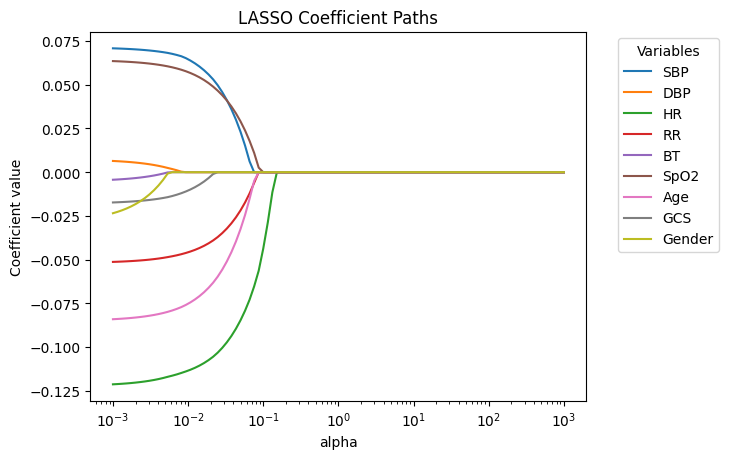

In [10]:
# Code to create a figure of the coefficients as we change the alpha term
plt.figure()

# Looping over the coefficients
for i in range(coefs.shape[1]):
    # Creating a plot for each variable
    # Showing the coefficient over differnt values of alpha
    plt.plot(alpha_grid, coefs[:, i], label=var_names[i])

# Plotting on the log scales
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title = 'Variables')
plt.show()

## Lasso
- The "LASSO" term stands for Least Asymptotic Shrinkage and Selection Operator

- You can see how it starts pushing DBP, BT, Gender, and GCS towards zero, and actually leaves the other variables in.

- As $\alpha$ increases, and the constraint increases, it finally starts shrinking the other variables, until all the coefficients are eventually zero

- This gives us a way of strategically, optimally reduce model variance

- Notice that when the coefficient hits zero, we can drop it from the model: This picks our model for us

- This is a wildly useful tool

## Getting Started with Ridge
- Almost everything is the same, except `from sklearn.linear_model import Ridge`

In [11]:
# Repeat the same process, this time with Ridge regression instead of LASSO
from sklearn.linear_model import Ridge

# Use the same alpha grid
# Initialize a matrix to store coefficients
coefs = np.zeros((len(alpha_grid), X.shape[1]))

# Loop through each alpha value
for i, alpha in enumerate(alpha_grid):
    # Fit Ridge model with this alpha
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X, y)
    
    # Store the coefficients
    coefs[i, :] = ridge_model.coef_

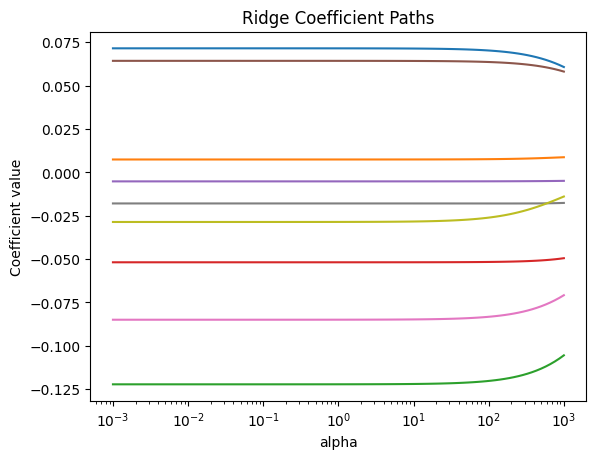

In [12]:
# Same plot as before, this time looking at Ridge Regression
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths")
plt.show()

## Lasso versus Ridge

- Remember from the previous graph that LASSO sends the coefficeints to zero as $\alpha$ increases. In other words, it removes variables from the model and selects a model specification for you.

- Notice in this new graph how Ridge smoothly shrinks all the coefficients towards zero: It never removes a variable completely.

- The LASSO penalty, $\alpha ( |b_1| + |b_2| + ... + |b_L| )$, has points of non-differentiability at 0, or "corners"

- The Ridge penalty, $\alpha ( b_1^2 + b_2^2 + ... + b_L^2 )$, is smooth at zero, and increases faster than $|b_\ell|$

- As a result, LASSO "zeros out" variables and selects a specific model, while Ridge smoothly shrinks all the coefficients towards 0

- Ridge typically performs better, while the LASSO provides more interpretable results

## This Fixes "Big Feature Spaces"
- Now, we can build big feature spaces AND avoid overfitting: Use your `degree=K`, but add regularization to shrink non-performant predictors away
- Now, it's only a matter of computational time/power to build useful models

In [13]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Defining a polynomial expander of degree 2 for all features
expander = PolynomialFeatures(degree=2 ,include_bias=False, interaction_only=False)

# Expanding the results and getting their names
X_poly = expander.fit_transform(X_numeric)
poly_names = expander.get_feature_names_out()

# Turn it back to a data frame so that we can concatenate with the categorical data
X_poly = pd.DataFrame(X_poly, columns = poly_names)
X_poly.head()

,SBP,DBP,HR,RR,BT,SpO2,Age,GCS,SBP^2,SBP DBP,...,BT^2,BT SpO2,BT Age,BT GCS,SpO2^2,SpO2 Age,SpO2 GCS,Age^2,Age GCS,GCS^2
0,1.827080,0.882066,0.836171,-0.436331,-0.378704,0.107207,0.403036,-0.090103,3.338222,1.611605,...,0.143417,-0.0406,-0.152632,0.034123,0.011493,0.043208,-0.00966,0.162438,-0.036315,0.008119
1,0.608476,0.467308,0.559738,-0.948447,-0.378704,0.107207,0.403036,-0.090103,0.370244,0.284346,...,0.143417,-0.0406,-0.152632,0.034123,0.011493,0.043208,-0.00966,0.162438,-0.036315,0.008119
2,0.062206,0.135502,0.283304,-0.265625,-0.378704,0.107207,0.403036,-0.090103,0.003870,0.008429,...,0.143417,-0.0406,-0.152632,0.034123,0.011493,0.043208,-0.00966,0.162438,-0.036315,0.008119
3,-0.694169,0.176978,-0.269562,-0.777742,-0.378704,0.107207,0.403036,-0.090103,0.481870,-0.122852,...,0.143417,-0.0406,-0.152632,0.034123,0.011493,0.043208,-0.00966,0.162438,-0.036315,0.008119
4,-0.988314,-0.154828,-0.877716,-1.289858,-0.378704,0.107207,0.403036,-0.090103,0.976765,0.153019,...,0.143417,-0.0406,-0.152632,0.034123,0.011493,0.043208,-0.00966,0.162438,-0.036315,0.008119


In [14]:
# Repeat the process of fitting a LASSO regression model
# Now with a more complex model
# Combine the polynomial features with the categorical variable
X_combined = pd.concat([X_poly, X_categorical], axis=1)

# Scale the combined features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_combined),
    columns=X_combined.columns
)

# Initialize a matrix to store coefficients
coefs = np.zeros((len(alpha_grid), X_scaled.shape[1]))

# Loop through each alpha value
for i, alpha in enumerate(alpha_grid):
    # Fit LASSO model with this alpha
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_scaled, y)
    
    # Store the coefficients
    coefs[i, :] = lasso_model.coef_

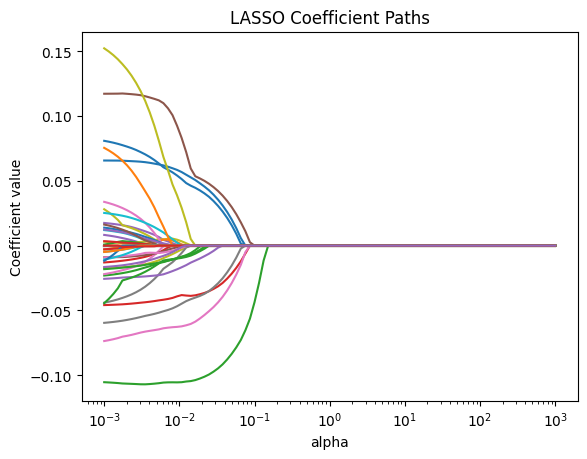

In [15]:
# Plotting the figure of the coefficeints over time
plt.figure()
for i in range(coefs.shape[1]):
    # Have to update the plotting code to include the poly_names
    plt.plot(alpha_grid, coefs[:, i], label=X_scaled.columns[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")

# Not including the legend because we have so many features now
#plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# 2. Cross-validating the Cost Hyperparameter, $\alpha$

## Picking the $\alpha$
- The $\alpha$ is a key hyperparameter! How do we pick the cost of purchasing coefficient?

- To decide which penalty value, we cross validate:
    1. Pick a grid of $\alpha$ values
    2. For each $\alpha$ value, use KFold CV:
        - Pick the coefficients to minimize $MSE(\hat{b})+\alpha |\hat{b}|$ or $MSE(\hat{b})+\alpha \hat{b}^2$ on the training folds
        - Evaluate $MSE(\hat{b})$ on the test folds and save the estimate
    3. Pick the mean/median value of $MSE(\hat{b})$ for that $\alpha$
    4. Pick the $\alpha$ that minimizes the mean/median value of $MSE(\hat{b})$ across the grid

- This automatically generates the paths of the coefficients as the cost $\alpha$ varies, so you can see how variable the coefficients are in the underlying cost

## Scikit Implementation
Of course, that's a complex procedure, and Scikit offers tools for this:

- `model = LassoCV(cv=10, random_state=100).fit(X,y)` will do the $k$-fold cross validation and compute the best model
  - `model.mse_path_` has the stored mean squared error values
  - `mean_mse = model.mse_path_.mean(axis=1)` or `median_mse = model.mse_path_.median(axis=1)` provide the mean/median cross-validated mean squared error

- `alpha, coef_path, _ = lasso_path(X,y,alpha)` creates the data for the plots, like what we were doing manually above

In [16]:
# Perform Cross Validated CV to identify the best value of alpha to use
from sklearn.linear_model import LassoCV

# Fit a LassoCV model with 10-fold cross validation
model = LassoCV(cv=10, random_state=100, max_iter=10000)
model.fit(X_scaled, y)

# Store the optimal alpha value
alpha_star = model.alpha_

In [17]:
# Look at the mse path, what's the shape and what does it represent?
# How can we identify the best alpha?
print(f"MSE path shape: {model.mse_path_.shape}")
print(f"This represents: ({model.mse_path_.shape[0]} alpha values, {model.mse_path_.shape[1]} CV folds)")
print(f"\nNumber of alphas tested: {len(model.alphas_)}")
print(f"Best alpha (alpha_star): {alpha_star}")

# We can identify the best alpha by finding the one that minimizes the median MSE across folds
median_mse = np.median(model.mse_path_, axis=1)
best_alpha_idx = np.argmin(median_mse)
print(f"Alpha at minimum median MSE: {model.alphas_[best_alpha_idx]}")

MSE path shape: (100, 10)
This represents: (100 alpha values, 10 CV folds)

Number of alphas tested: 100
Best alpha (alpha_star): 0.008222804261320668
Alpha at minimum median MSE: 0.13401122107809546


Optimal cost hyperparameter: 0.008222804261320668


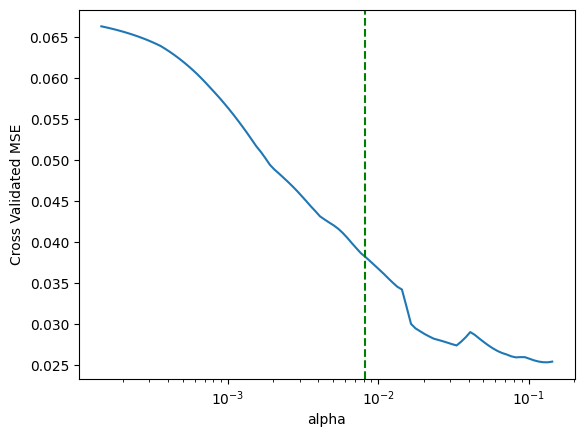

In [18]:
# Plot the median MSE Across Alpha Values
sns.lineplot(
    x = model.alphas_,
    y= np.median(model.mse_path_,axis=1)
)

# Plot a line where the minimum MSE is achieved
plt.axvline(
    x=alpha_star,
    color='green',
    linestyle='--',
    linewidth=1.5
)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

We can look at the trajectories of the coefficients:

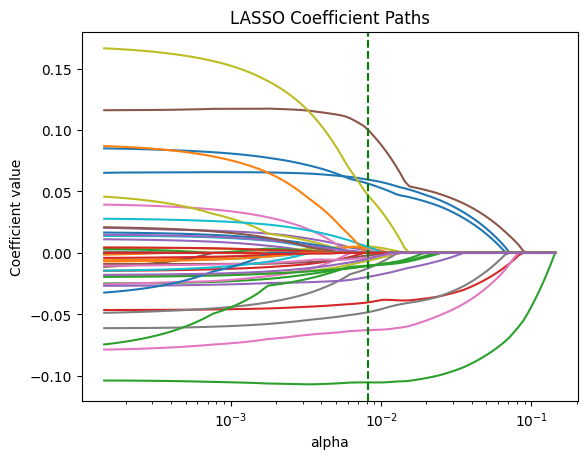

In [19]:
# Plot the lasso_path using the lasso_path function
from sklearn.linear_model import lasso_path

# Use lasso_path to compute the coefficient paths
alphas, coef_path, _ = lasso_path(X_scaled, y, alphas=model.alphas_)

# Plot the coefficient paths
plt.figure()
for i in range(coef_path.shape[0]):
    plt.plot(alphas, coef_path[i, :])

# Same Labels as usual
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

## Key Insights
- LASSO will zero coefficients out and automatically select a model for you
- Ridge will shrink all of the coefficients, but not really to zero
- This means LASSO is interpretable like linear regression: It literally decides what variables go in the model
- In practice, however, Ridge typically does better at prediction
- Now, no matter how big the feature space is, in principle you have a way to control your model's tendency to overfit

## Conclusion
- This is one of the most powerful ML toolboxes available
- It is hard to understate how important regularization is; even neural networks typically need regularization to work well
- Now you can tame any feature space: Be creative and exploit your data and machine, and let the regulariation sort it out
- These models evolve into neural networks, with thousands and millions and billions and trillions of weights: The secret to stable calculation and robust prediction is finding a way to avoid over-fitting, and the tool is very often regularization
- The LASSO provides an interpretable result, but L2 typically works better in practice
- Your coefficients are explicitly biased, but we are worried about prediction, not inference (and inference with the LASSO is an active area of research)